C:\Users\tsift\AppData\Local\Temp\ipykernel_2688\300412902.py:18: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])


Urban–Rural classes found (rows):
urban_rural_class
1    1243753
2     201704
3      83893
Name: count, dtype: int64

Urban–Rural classes found (unique homes):
urban_rural_class
1    196
2     38
3     20
Name: home_id, dtype: int64


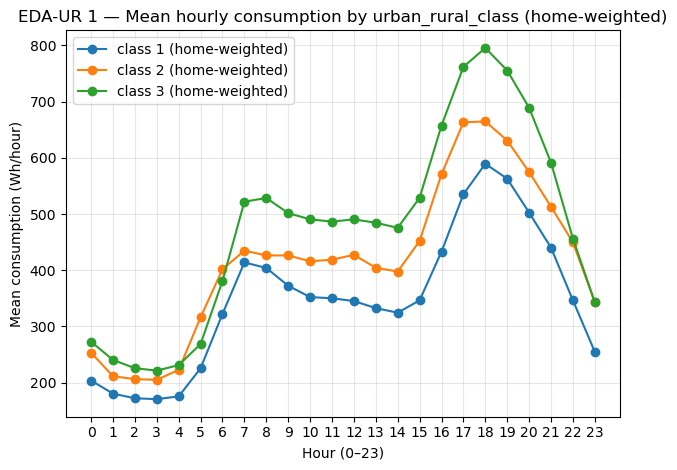

Saved: C:\IDEAL_Programming\processed\plots\eda_new\by_urban_rural_class\EDA_UR_01_mean_consumption_by_hour_weighted.png


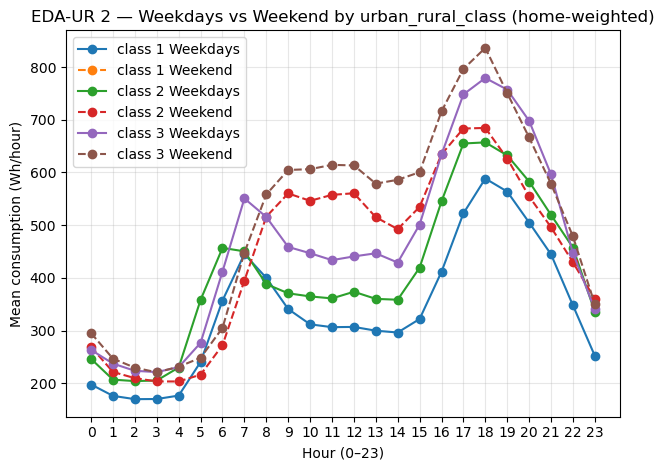

Saved: C:\IDEAL_Programming\processed\plots\eda_new\by_urban_rural_class\EDA_UR_02_weekday_weekend_by_hour_weighted.png

EDA-UR 3 (class 1) rows before dropna: 1243753, after: 1243753, dropped: 0

EDA-UR 3 (class 2) rows before dropna: 201704, after: 201704, dropped: 0

EDA-UR 3 (class 3) rows before dropna: 83893, after: 83893, dropped: 0


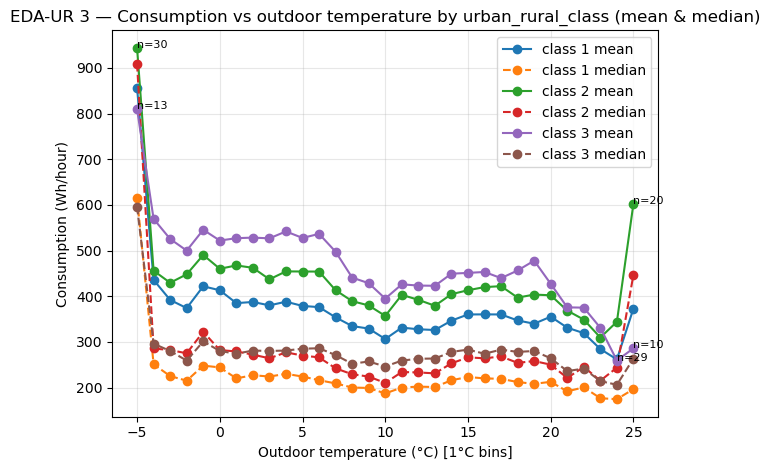

Saved: C:\IDEAL_Programming\processed\plots\eda_new\by_urban_rural_class\EDA_UR_03_consumption_vs_outdoor_temp_mean_median.png

EDA-UR 4 homes per class:
 urban_rural_class
1    196
2     38
3     20
Name: home_id, dtype: int64


C:\Users\tsift\AppData\Local\Temp\ipykernel_2688\300412902.py:189: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_class, labels=labels, showfliers=True)


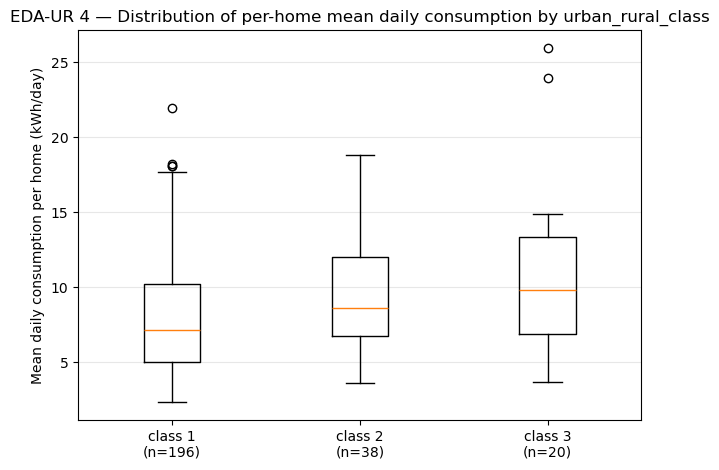

Saved: C:\IDEAL_Programming\processed\plots\eda_new\by_urban_rural_class\EDA_UR_04_mean_daily_kWh_boxplot_showfliers.png

Plots saved to: C:\IDEAL_Programming\processed\plots\eda_new\by_urban_rural_class


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Paths
# =========================
BASE_DIR = Path("C:/IDEAL_Programming")
DATA_PATH = BASE_DIR / "processed" / "final" / "IDEAL_final_hourly_dataset.csv"

# NEW folder to avoid mixing with older plots
PLOTS_DIR = BASE_DIR / "processed" / "plots" / "eda_new" / "by_urban_rural_class"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Load
# =========================
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])

need = ["home_id", "timestamp", "consumption_Wh", "urban_rural_class", "is_weekend", "external_temperature"]
missing = [c for c in need if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["hour"] = df["timestamp"].dt.hour
df["date"] = df["timestamp"].dt.date

# =========================
# Fix / normalize urban_rural_class
# Keep 1,2 and map '3+' -> 3
# =========================
df["urban_rural_class"] = (
    df["urban_rural_class"]
      .astype(str)
      .str.strip()
      .replace({"3+": "3"})
)

df["urban_rural_class"] = pd.to_numeric(df["urban_rural_class"], errors="coerce")

# Keep only valid
df = df[df["urban_rural_class"].notna()].copy()

# Optional: enforce only 1,2,3 (drop other unexpected values)
df = df[df["urban_rural_class"].isin([1, 2, 3])].copy()

classes = sorted(df["urban_rural_class"].unique())

print("Urban–Rural classes found (rows):")
print(df["urban_rural_class"].value_counts().sort_index())

print("\nUrban–Rural classes found (unique homes):")
print(df.groupby("urban_rural_class")["home_id"].nunique().sort_index())

def save_show(name: str):
    out = PLOTS_DIR / name
    plt.tight_layout()
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

# ==========================================================
# Plot 1 (Improved): Mean hourly consumption by class (home-weighted)
# ==========================================================
plt.figure()
for c in classes:
    g = df[df["urban_rural_class"] == c]

    hw = (
        g.groupby(["home_id", "hour"])["consumption_Wh"].mean()
         .reset_index()
         .groupby("hour")["consumption_Wh"].mean()
         .sort_index()
    )

    plt.plot(hw.index, hw.values, marker="o", label=f"class {int(c)} (home-weighted)")

plt.xlabel("Hour (0–23)")
plt.ylabel("Mean consumption (Wh/hour)")
plt.title("EDA-UR 1 — Mean hourly consumption by urban_rural_class (home-weighted)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
save_show("EDA_UR_01_mean_consumption_by_hour_weighted.png")

# ==========================================================
# Plot 2 (Improved): Weekdays vs Weekend by class (home-weighted)
# ==========================================================
plt.figure()
for c in classes:
    g = df[df["urban_rural_class"] == c]

    wd = (
        g[g["is_weekend"] == 0]
        .groupby(["home_id", "hour"])["consumption_Wh"].mean()
        .reset_index()
        .groupby("hour")["consumption_Wh"].mean()
        .sort_index()
    )

    we = (
        g[g["is_weekend"] == 1]
        .groupby(["home_id", "hour"])["consumption_Wh"].mean()
        .reset_index()
        .groupby("hour")["consumption_Wh"].mean()
        .sort_index()
    )

    plt.plot(wd.index, wd.values, marker="o", label=f"class {int(c)} Weekdays")
    plt.plot(we.index, we.values, marker="o", linestyle="--", label=f"class {int(c)} Weekend")

plt.xlabel("Hour (0–23)")
plt.ylabel("Mean consumption (Wh/hour)")
plt.title("EDA-UR 2 — Weekdays vs Weekend by urban_rural_class (home-weighted)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
save_show("EDA_UR_02_weekday_weekend_by_hour_weighted.png")

# ==========================================================
# Plot 3 (Improved): Consumption vs outdoor temp by class
# - 1°C bins
# - mean + median
# - annotate sparse bins
# ==========================================================
plt.figure()

for c in classes:
    g = df[df["urban_rural_class"] == c][["external_temperature", "consumption_Wh"]].copy()

    before = len(g)
    g = g.dropna()
    after = len(g)
    print(f"\nEDA-UR 3 (class {int(c)}) rows before dropna: {before}, after: {after}, dropped: {before - after}")

    g["temp_bin"] = g["external_temperature"].round(0).astype(int)

    stats = (
        g.groupby("temp_bin")["consumption_Wh"]
         .agg(mean="mean", median="median", count="count")
         .reset_index()
         .sort_values("temp_bin")
    )

    plt.plot(stats["temp_bin"], stats["mean"], marker="o", label=f"class {int(c)} mean")
    plt.plot(stats["temp_bin"], stats["median"], marker="o", linestyle="--", label=f"class {int(c)} median")

    # annotate sparse bins
    sparse = stats[stats["count"] < 50]
    for _, r in sparse.iterrows():
        plt.text(r["temp_bin"], r["mean"], f"n={int(r['count'])}", fontsize=8)

plt.xlabel("Outdoor temperature (°C) [1°C bins]")
plt.ylabel("Consumption (Wh/hour)")
plt.title("EDA-UR 3 — Consumption vs outdoor temperature by urban_rural_class (mean & median)")
plt.grid(True, alpha=0.3)
plt.legend()
save_show("EDA_UR_03_consumption_vs_outdoor_temp_mean_median.png")

# ==========================================================
# Plot 4 (Improved): Mean daily kWh per home by class (boxplot)
# - showfliers=True
# - annotate n homes per class
# ==========================================================
daily = (
    df.groupby(["home_id", "urban_rural_class", "date"])["consumption_Wh"]
      .sum()
      .reset_index()
)

mean_daily = (
    daily.groupby(["home_id", "urban_rural_class"])["consumption_Wh"]
         .mean()
         .reset_index()
)

mean_daily["mean_daily_kWh"] = mean_daily["consumption_Wh"] / 1000.0

home_counts = mean_daily.groupby("urban_rural_class")["home_id"].nunique().sort_index()
print("\nEDA-UR 4 homes per class:\n", home_counts)

data_by_class = [
    mean_daily.loc[mean_daily["urban_rural_class"] == c, "mean_daily_kWh"].values
    for c in classes
]
labels = [f"class {int(c)}\n(n={home_counts.get(c, 0)})" for c in classes]

plt.figure()
plt.boxplot(data_by_class, labels=labels, showfliers=True)
plt.ylabel("Mean daily consumption per home (kWh/day)")
plt.title("EDA-UR 4 — Distribution of per-home mean daily consumption by urban_rural_class")
plt.grid(True, axis="y", alpha=0.3)
save_show("EDA_UR_04_mean_daily_kWh_boxplot_showfliers.png")

print("\nPlots saved to:", PLOTS_DIR)
